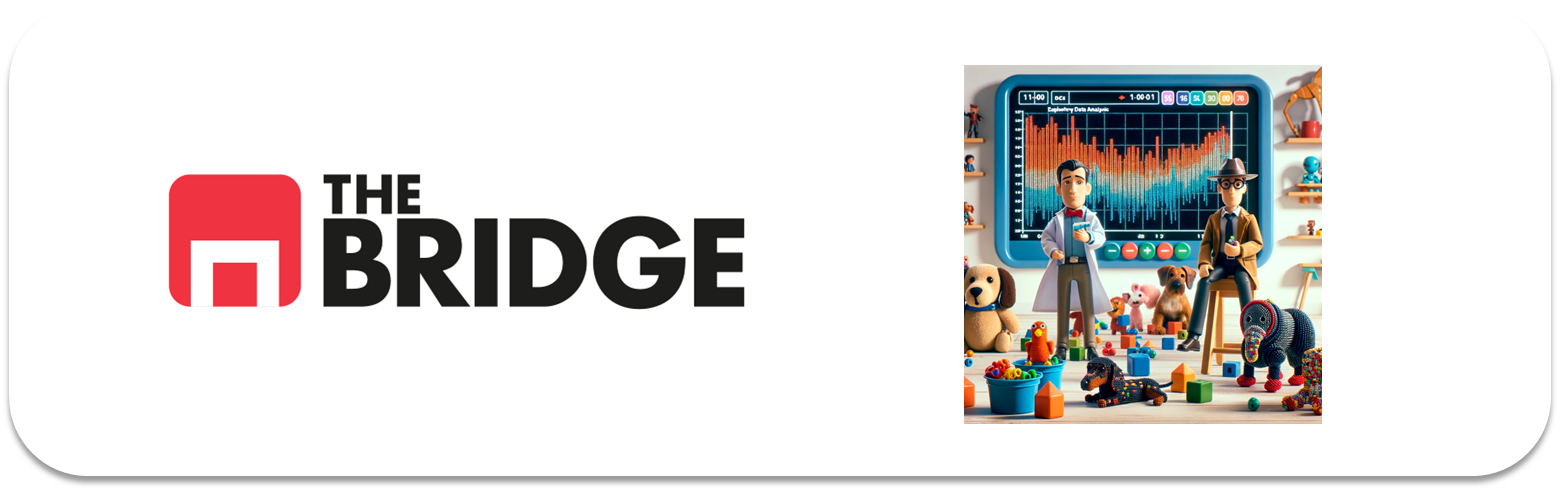

## PRACTICA OBLIGATORIA: **Análisis Multivariante**

* La práctica obligatoria de esta unidad consiste en completar el análisis del dataset del Titanic, dirigido por una serie de preguntas, y de terminar de analizar algunos aspectos del dataset de viajes. Descarga este notebook en tu ordenador y trabaja en local. Ten en cuenta que tendrás que descar los directorios de imágenes y datos adicionales, si los hubiera.
* Recuerda que debes subirla a tu repositorio personal antes de la sesión en vivo para que puntúe adecuadamente.  
* Recuerda también que no es necesario que esté perfecta, sólo es necesario que se vea el esfuerzo. 
* Esta práctica se resolverá en la sesión en vivo correspondiente y la solución se publicará en el repo del curso. 

### Ejercicio 0


Importa los paquetes y módulos que necesites a lo largo del notebook

In [1]:
# Paquetes base para manipulación, visualización y contrastes estadísticos
import pandas as pd
import bootcampviztools as bvt
import matplotlib.pyplot as plt


from scipy.stats import chi2_contingency, mannwhitneyu

## #1: Titanic

### #1.1

Carga en un dataframe el dataset del titanic, que está en la ruta "./data/titanic.csv".

In [2]:
# Cargamos el Titanic y nos quedamos con una copia de trabajo para no tocar el original
df_titanic = pd.read_csv("./data/titanic.csv")
df = df_titanic.copy()
df.head()

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True


### #1.2

Deshazte de las columnas "deck", "survived", "pclass" y "embarked" porque no las emplearemos, la primera por su cantidad de nulos y el resto porque son variantes de otras que ya existen y cuyos valores resultan más expresivos a la hora de hacer un análisis. 

In [3]:
# Eliminamos columnas redundantes o poco útiles para el análisis
columnas_a_eliminar = ["deck", "survived", "pclass", "embarked"]
df = df.drop(columns=columnas_a_eliminar)

### #1.3

Suma las columnas "parch" y "sibsp" para tener el número de parientes de cada pasajero, guarda el resultado en otra columna "family_members", luego deshazte de "parch" y "sibsp"

In [4]:
# Sumamos los parientes a bordo y guardamos el total en una nueva variable
df["family_members"] = df[["parch", "sibsp"]].sum(axis=1)
df = df.drop(columns=["parch", "sibsp"])

### #1.4

Imputa la moda a los valores nulos de "embark_town"

In [5]:
# Imputamos los nulos con la moda de la ciudad de embarque
moda_embark_town = df["embark_town"].mode(dropna=True)[0]
df["embark_town"] = df["embark_town"].fillna(moda_embark_town)

### #1.5

Imputa la media a los valores faltantes de "age", si quieres puedes hacer algo más preciso (por ejemplo considerando además la columna "who")

In [6]:
# Creamos una columna booleana para marcar qué filas tenían la edad nula antes de imputar
df["age_imputed"] = df["age"].isna()

# Calculamos la media global de edad (se usará como respaldo final)
media_edad_global = df["age"].mean()

# Calculamos la media de edad por cada categoría de 'who' (child, man, woman)
medias_edad_por_grupo = df.groupby("who", dropna=False)["age"].mean()

# Recorremos cada grupo y rellenamos los nulos de edad con la media de su propio grupo
for grupo, media_grupo in medias_edad_por_grupo.items():
    # Máscara: filas del grupo actual con edad nula
    mascara = df["who"].eq(grupo) & df["age"].isna()

    # Solo imputamos si la media del grupo existe (no es NaN)
    if pd.notna(media_grupo):
        df.loc[mascara, "age"] = media_grupo

# Si todavía queda algún nulo, lo rellenamos con la media global
df["age"] = df["age"].fillna(media_edad_global)

### #1.6

Realiza los análisis bivariantes o multivariantes que necesites, así como los test de hipótesis necesarios para contestar a las siguientes preguntas. Nota: utiliza la variable "alive" para saber si un pasajero sobrevivió o no:

1. En términos absolutos, ¿sobrevivieron más hombres, mujeres o niños? ¿Y en términos relativos? ¿Existe alguna relación estadísticamente significativa entre el sexo y la supervivencia en el Titanic?¿Y entre ser adulto o ser niño?

2. En términos absolutos, ¿de que clase sobrevivieron más pasajeros?¿ Y en términos relativos? ¿Existe alguna relación estadísticamente significativa entre la clase en la que se viajaba y la supervivencia?

3. ¿De qué ciudad sobrevivieron más personas?¿Y porcentualmente de que ciudad sobrevivieron más personas? ¿Hay alguna relación estadística significativa entre haber embarcado en una de las tres ciudades y haber sobrevivido o fallecido?

4. ¿Qué relación hay entre el precio del pasaje y la supervivencia/fallecimiento?

5. Existen pasajero que no pagaron el billete, ¿podrías explicar por qué? ¿Qué ocurrió con la persona que más dinero se dejó?

6. Existe alguna relación entre el dinero pagado, la ciudad de embarque y la superviviencia/fallecimiento. No necesitas aplicar ningún test, muestralo numérica o visualmente.

7. Ahondando en la relación entre sobrevivir o fallecer, la clase en la que se viajó y la edad de los pasajeros. ¿Qué agrupación de las dos variables (clase y edad) sobrevivió más en términos absolutos y en términos relativos?

8. Finalmente, muestra las posibles relaciones entre edad, coste del billete y supervivencia/fallecimiento. ¿Qué puedes decir al respecto?

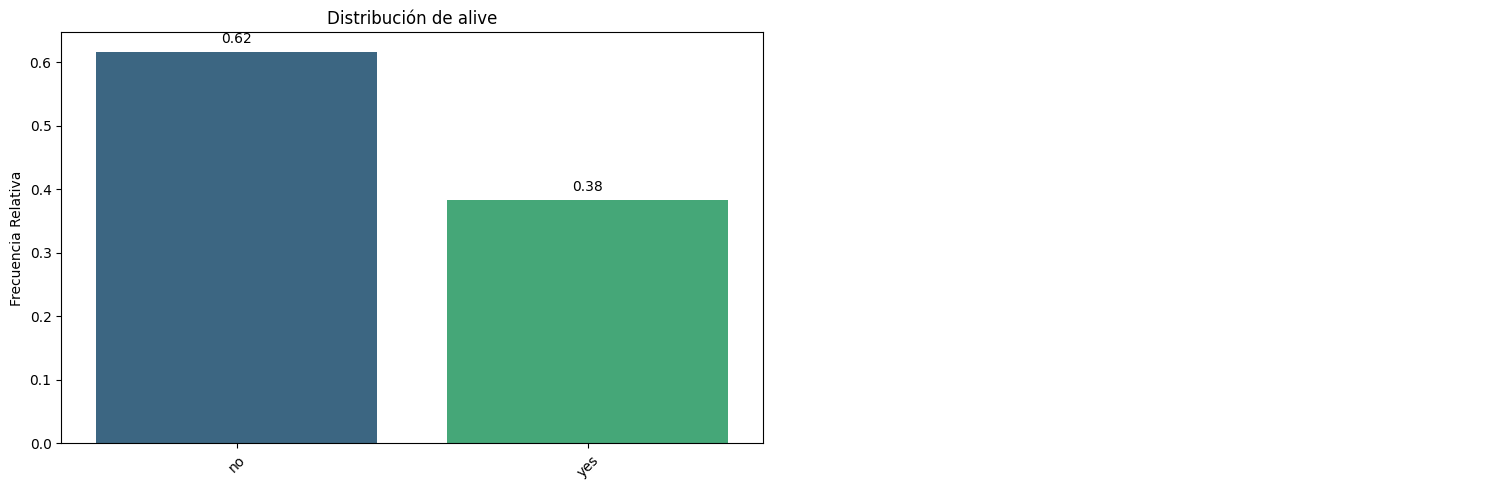

In [20]:
# Miramos primero la variable objetivo
bvt.pinta_distribucion_categoricas(df, ["alive"], relativa=True, mostrar_valores=True)

In [8]:
# Función auxiliar
def resumen_chi2(tabla_contingencia):
    chi2, p_value, dof, expected = chi2_contingency(tabla_contingencia)
    print(f"Chi2 = {chi2:.4f}")
    print(f"p-value = {p_value:.6f}")
    print(f"Grados de libertad = {dof}")
    print("Frecuencias esperadas:")
    print(expected)
    return p_value

def comparar_categoricas(df_local, variable_x, variable_y, *, relativa=False):
    # variable_x se pinta en el eje X y variable_y actúa como variable de agrupación
    bvt.plot_categorical_relationship_fin(
        df_local,
        variable_x,
        variable_y,
        relative_freq=relativa,
        show_values=True,
    )
    tabla = pd.crosstab(df_local[variable_y], df_local[variable_x])
    print(pd.crosstab(df_local[variable_x], df_local[variable_y], margins=True))
    return resumen_chi2(tabla)


1. En términos absolutos, ¿sobrevivieron más hombres, mujeres o niños? ¿Y en términos relativos? ¿Existe alguna relación estadísticamente significativa entre el sexo y la supervivencia en el Titanic?¿Y entre ser adulto o ser niño?

alive   no  yes
who            
child   34   49
man    449   88
woman   66  205


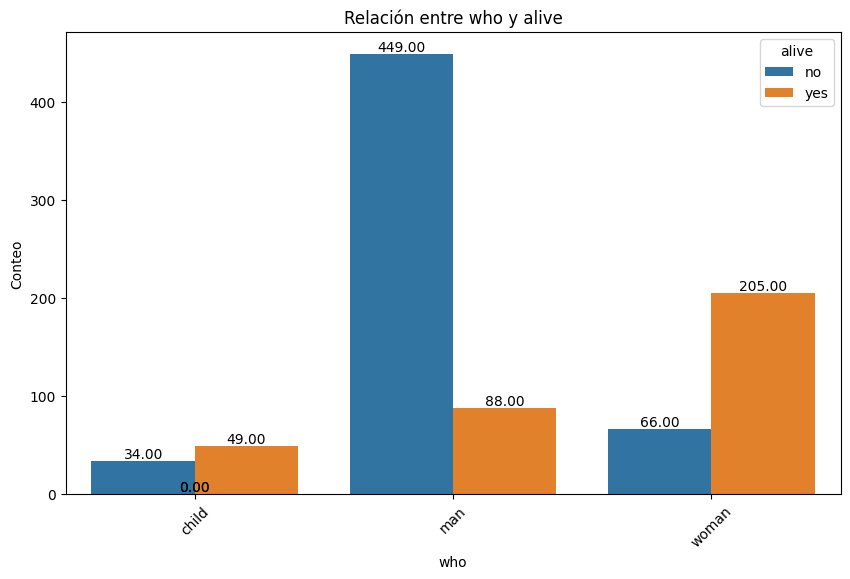

alive   no  yes  All
who                 
child   34   49   83
man    449   88  537
woman   66  205  271
All    549  342  891
Chi2 = 283.9231
p-value = 0.000000
Grados de libertad = 2
Frecuencias esperadas:
[[ 51.14141414 330.87878788 166.97979798]
 [ 31.85858586 206.12121212 104.02020202]]


np.float64(2.2227620817798914e-62)

In [21]:
# 1) Análisis por sexo/grupo ("who") y por grupo de edad (niño vs adulto)

# Creamos una variable binaria de edad a partir de "who":
# - child  -> "niño"
# - man/woman -> "adulto"
df["grupo_edad"] = df["who"].map(lambda valor: "niño" if valor == "child" else "adulto")

# Mostramos tabla de frecuencias absolutas de supervivencia por categoría de "who"
print(df.groupby(["who", "alive"]).size().unstack(fill_value=0))

# Visualización y contraste chi-cuadrado en términos absolutos (who vs alive)
comparar_categoricas(df, "who", "alive", relativa=False)


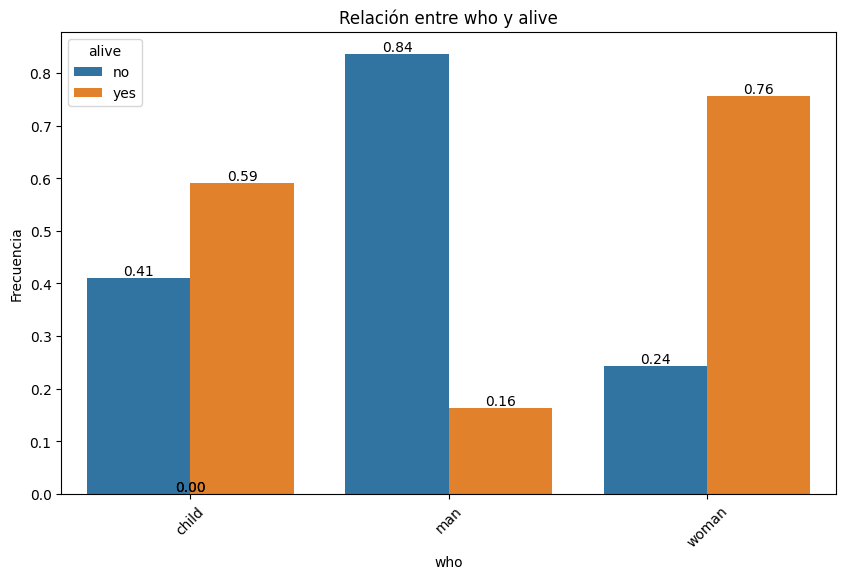

alive   no  yes  All
who                 
child   34   49   83
man    449   88  537
woman   66  205  271
All    549  342  891
Chi2 = 283.9231
p-value = 0.000000
Grados de libertad = 2
Frecuencias esperadas:
[[ 51.14141414 330.87878788 166.97979798]
 [ 31.85858586 206.12121212 104.02020202]]


np.float64(2.2227620817798914e-62)

In [22]:
# Visualización y contraste chi-cuadrado en términos relativos (proporciones)
comparar_categoricas(df, "who", "alive", relativa=True)

En valor absoluto, murieron más hombres que mujeres y niños. En valores relativo, también se corrobora que hubo una mortalidad más alta

alive        no  yes
grupo_edad          
adulto      515  293
niño         34   49


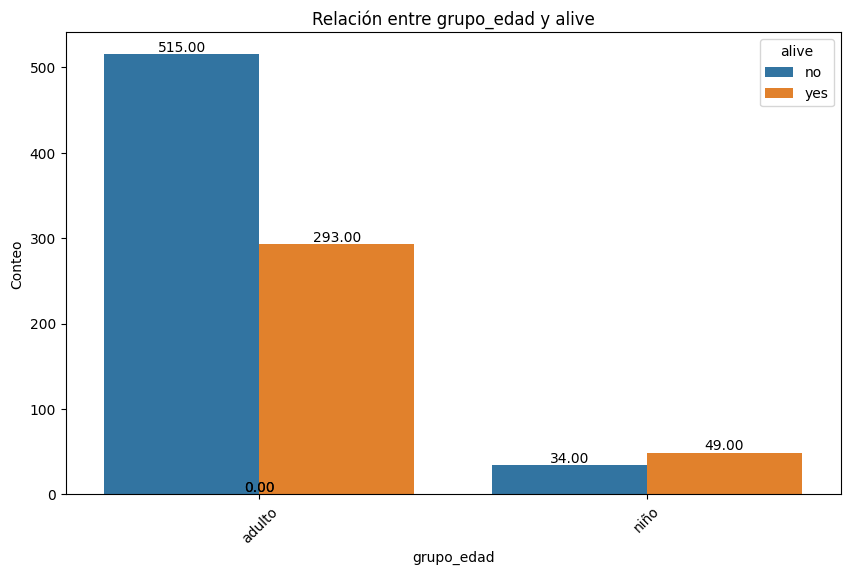

alive        no  yes  All
grupo_edad               
adulto      515  293  808
niño         34   49   83
All         549  342  891
Chi2 = 15.5570
p-value = 0.000080
Grados de libertad = 1
Frecuencias esperadas:
[[497.85858586  51.14141414]
 [310.14141414  31.85858586]]


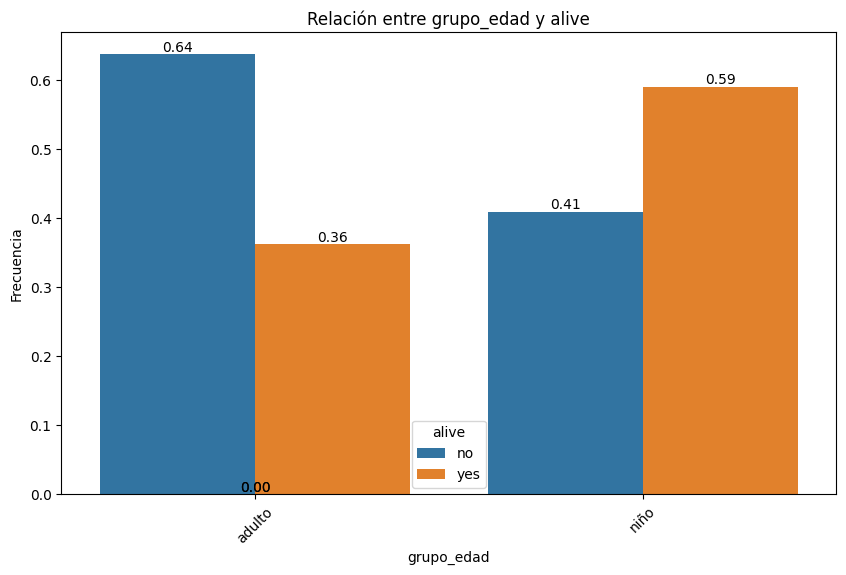

alive        no  yes  All
grupo_edad               
adulto      515  293  808
niño         34   49   83
All         549  342  891
Chi2 = 15.5570
p-value = 0.000080
Grados de libertad = 1
Frecuencias esperadas:
[[497.85858586  51.14141414]
 [310.14141414  31.85858586]]


np.float64(8.005497211300105e-05)

In [23]:
# Mostramos tabla de frecuencias absolutas de supervivencia por grupo de edad simplificado
print(df.groupby(["grupo_edad", "alive"]).size().unstack(fill_value=0))

# Visualización y contraste chi-cuadrado en términos absolutos (grupo_edad vs alive)
comparar_categoricas(df, "grupo_edad", "alive", relativa=False)

# Visualización y contraste chi-cuadrado en términos relativos (proporciones)
comparar_categoricas(df, "grupo_edad", "alive", relativa=True)

Se corrobora que estadisticamente murieron más adultos que niños

2. En términos absolutos, ¿de que clase sobrevivieron más pasajeros?¿ Y en términos relativos? ¿Existe alguna relación estadísticamente significativa entre la clase en la que se viajaba y la supervivencia?

alive    no  yes
class           
First    80  136
Second   97   87
Third   372  119


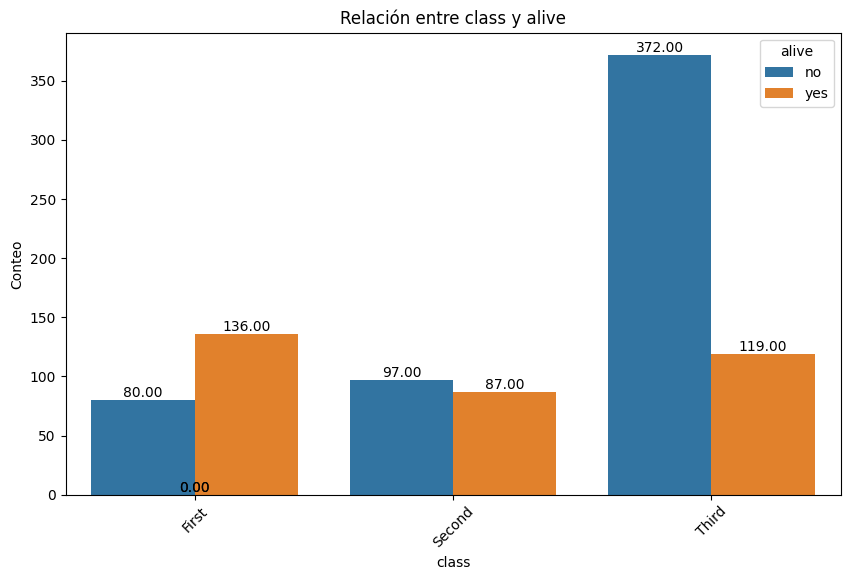

alive    no  yes  All
class                
First    80  136  216
Second   97   87  184
Third   372  119  491
All     549  342  891
Chi2 = 102.8890
p-value = 0.000000
Grados de libertad = 2
Frecuencias esperadas:
[[133.09090909 113.37373737 302.53535354]
 [ 82.90909091  70.62626263 188.46464646]]


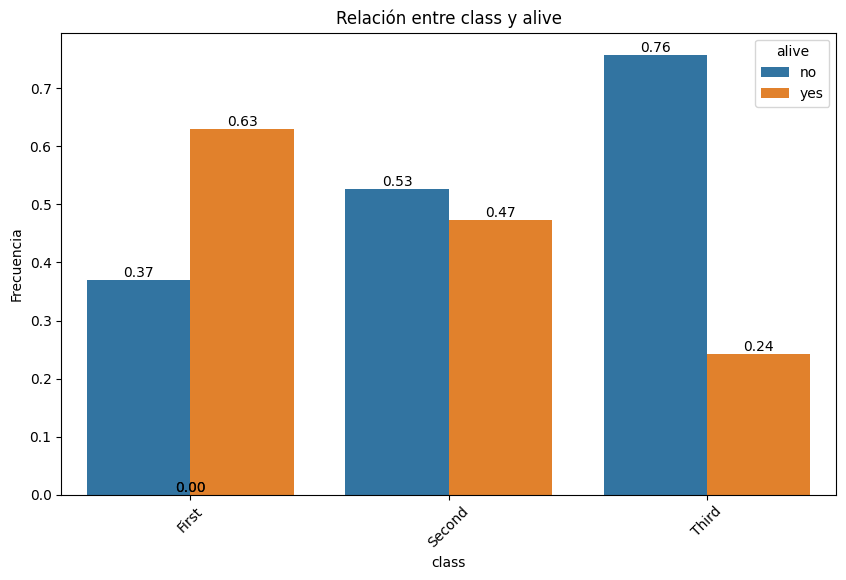

alive    no  yes  All
class                
First    80  136  216
Second   97   87  184
Third   372  119  491
All     549  342  891
Chi2 = 102.8890
p-value = 0.000000
Grados de libertad = 2
Frecuencias esperadas:
[[133.09090909 113.37373737 302.53535354]
 [ 82.90909091  70.62626263 188.46464646]]


np.float64(4.549251711298793e-23)

In [10]:
# 2) Análisis de la variable "class" frente a supervivencia ("alive")

# Mostramos una tabla de frecuencias absolutas:
# filas = clase del billete, columnas = sobrevivió/no sobrevivió
print(df.groupby(["class", "alive"]).size().unstack(fill_value=0))

# Representación en términos absolutos + test chi-cuadrado
# (sirve para ver si hay relación estadísticamente significativa entre clase y supervivencia)
comparar_categoricas(df, "class", "alive", relativa=False)

# Representación en términos relativos (porcentajes) + test chi-cuadrado
# (sirve para comparar mejor las proporciones entre clases)
comparar_categoricas(df, "class", "alive", relativa=True)

En términos absolutos, los de segunda clase fueron los que menor número de superviviente tuvieron. Sin embargo, en valores relativos, vemos que los más perjudicados son los de tercera clase, con un 76% de muertes.

3. ¿De qué ciudad sobrevivieron más personas?¿Y porcentualmente de que ciudad sobrevivieron más personas? ¿Hay alguna relación estadística significativa entre haber embarcado en una de las tres ciudades y haber sobrevivido o fallecido?

embark_town
Southampton    646
Cherbourg      168
Queenstown      77
Name: count, dtype: int64
alive         no  yes
embark_town          
Cherbourg     75   93
Queenstown    47   30
Southampton  427  219


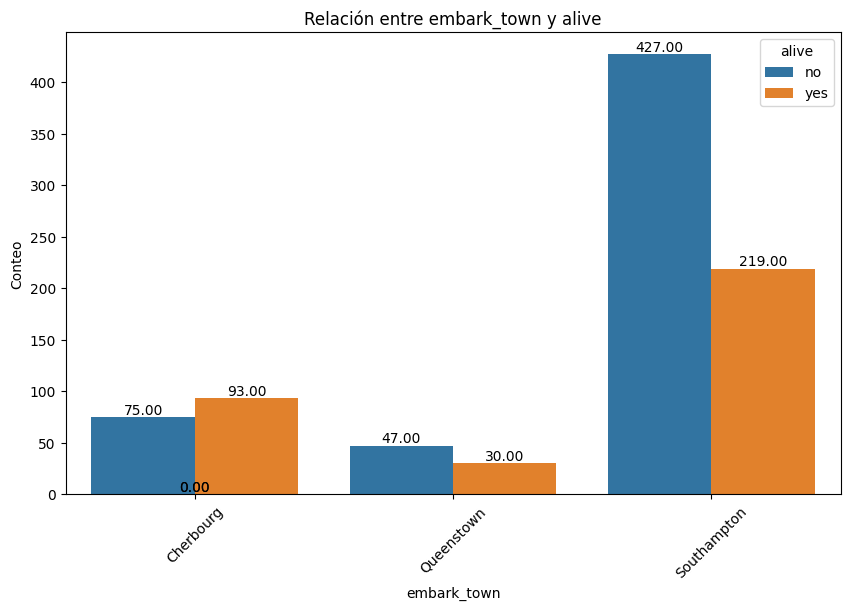

alive         no  yes  All
embark_town               
Cherbourg     75   93  168
Queenstown    47   30   77
Southampton  427  219  646
All          549  342  891
Chi2 = 25.9645
p-value = 0.000002
Grados de libertad = 2
Frecuencias esperadas:
[[103.51515152  47.44444444 398.04040404]
 [ 64.48484848  29.55555556 247.95959596]]


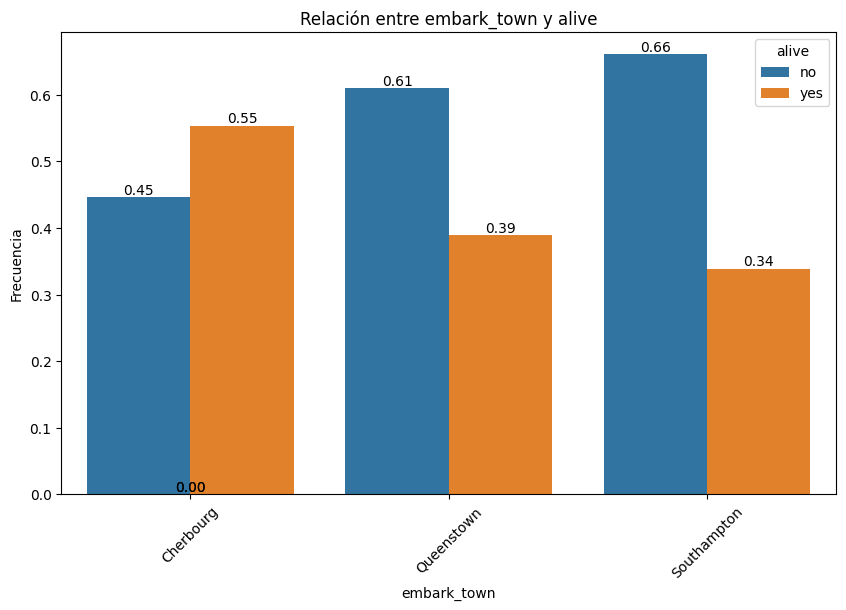

alive         no  yes  All
embark_town               
Cherbourg     75   93  168
Queenstown    47   30   77
Southampton  427  219  646
All          549  342  891
Chi2 = 25.9645
p-value = 0.000002
Grados de libertad = 2
Frecuencias esperadas:
[[103.51515152  47.44444444 398.04040404]
 [ 64.48484848  29.55555556 247.95959596]]
alive           no    yes
embark_town              
Cherbourg    0.446  0.554
Queenstown   0.610  0.390
Southampton  0.661  0.339


In [11]:
# 3) Análisis de la ciudad de embarque en relación con la supervivencia

# Mostramos el recuento de pasajeros por ciudad de embarque
print(df["embark_town"].value_counts())

# Tabla de frecuencias absolutas: filas = ciudad, columnas = sobrevivió/no sobrevivió
print(df.groupby(["embark_town", "alive"]).size().unstack(fill_value=0))

# Análisis bivariante en términos absolutos con test chi-cuadrado
comparar_categoricas(df, "embark_town", "alive", relativa=False)

# Análisis bivariante en términos relativos (porcentajes) con test chi-cuadrado
comparar_categoricas(df, "embark_town", "alive", relativa=True)

# Tabla que muestra los porcentajes de supervivencia/fallecimiento por ciudad de embarque
print(df.groupby("embark_town")["alive"].value_counts(normalize=True).unstack().round(3))


La ciudad de la que más personas sobrevivieron fue Southampton pero a su vez, proporcionalmente es la que más muertos tiene. Curiosamente el porcentaje de supervivencia en Chesbourg es superior al resto, puede deberse a la clase de las personas que embarcaron.

4. ¿Qué relación hay entre el precio del pasaje y la supervivencia/fallecimiento?

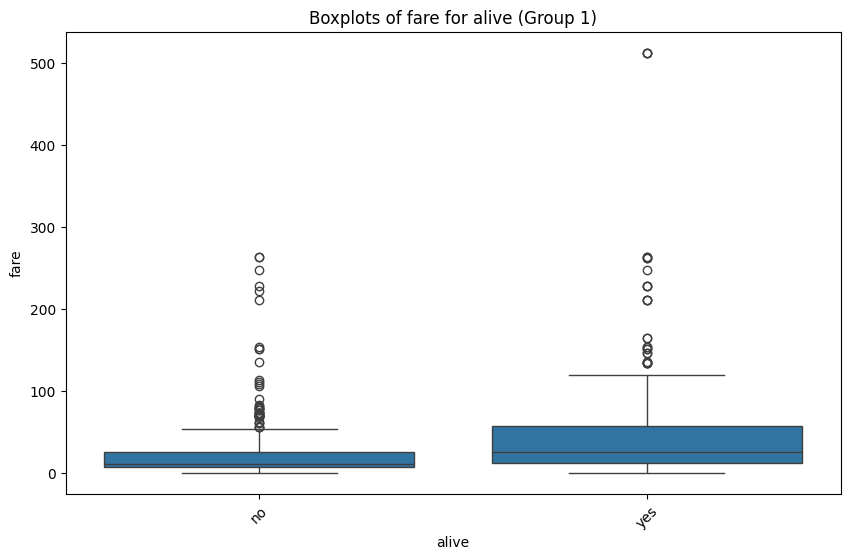

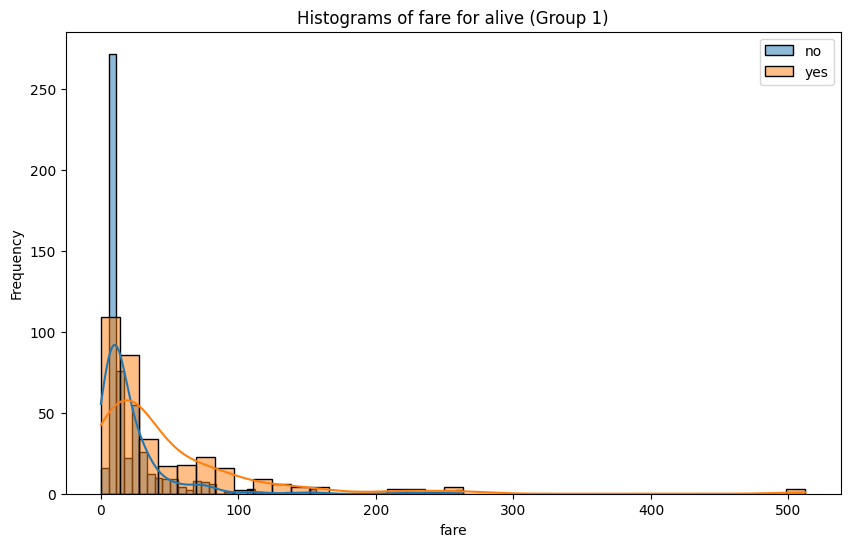

       count   mean  median    std
alive                             
no       549  22.12    10.5  31.39
yes      342  48.40    26.0  66.60
U = 129951.5000
p-value = 0.000000


In [12]:
# 4) Análisis del precio del billete en relación con la supervivencia

# Visualiza boxplots comparativos del precio del billete según si sobrevivió o no
bvt.plot_grouped_boxplots(df, "alive", "fare")

# Visualiza histogramas agrupados del precio del billete por supervivencia
bvt.plot_grouped_histograms(df, "alive", "fare", group_size=2)

# Calcula estadísticas descriptivas del precio: cantidad, media, mediana y desviación estándar
print(df.groupby("alive")["fare"].agg(["count", "mean", "median", "std"]).round(2))

# Realiza un test de Mann-Whitney U para comparar si hay diferencias estadísticamente 
# significativas entre los precios pagados por los que sobrevivieron vs los que no
u_stat, p_value = mannwhitneyu(
    df.loc[df["alive"] == "yes", "fare"],
    df.loc[df["alive"] == "no", "fare"],
    alternative="two-sided",
)

# Imprime el estadístico U y el p-valor del contraste
print(f"U = {u_stat:.4f}")
print(f"p-value = {p_value:.6f}")

Se observa que existen diferencias entre ambas distribuciones, siendo que los que murieron pagaron una tasa más baja que los que sobrevivieron

5. Existen pasajero que no pagaron el billete, ¿podrías explicar por qué? ¿Qué ocurrió con la persona que más dinero se dejó?

In [25]:
# 5) Billetes gratuitos y el mayor desembolso

# Mostramos las filas donde fare == 0 con algunas columnas de interés
print("Pasajeros con tarifa 0:")
display(df.loc[df["fare"] == 0, ["who", "class", "embark_town", "alone", "age", "fare"]])

# Contamos las combinaciones de who, class, embark_town y alone entre los que pagaron 0
print(df.loc[df["fare"] == 0, ["who", "class", "embark_town", "alone"]].value_counts())

# Mostramos la(s) fila(s) con la tarifa máxima y columnas relevantes (incluye si sobrevivió)
print("Pasajeros con la tarifa máxima:")
display(df.loc[df["fare"] == df["fare"].max(), ["who", "class", "embark_town", "alone", "age", "fare", "alive"]])

Pasajeros con tarifa 0:


,who,class,embark_town,alone,age,fare
179,man,Third,Southampton,True,36.000000,0.0
263,man,First,Southampton,True,40.000000,0.0
271,man,Third,Southampton,True,25.000000,0.0
277,man,Second,Southampton,True,33.173123,0.0
302,man,Third,Southampton,True,19.000000,0.0
413,man,Second,Southampton,True,33.173123,0.0
466,man,Second,Southampton,True,33.173123,0.0
481,man,Second,Southampton,True,33.173123,0.0
597,man,Third,Southampton,True,49.000000,0.0
633,man,First,Southampton,True,33.173123,0.0


who  class   embark_town  alone
man  Second  Southampton  True     6
     First   Southampton  True     5
     Third   Southampton  True     4
Name: count, dtype: int64
Pasajeros con la tarifa máxima:


,who,class,embark_town,alone,age,fare,alive
258,woman,First,Cherbourg,True,35.0,512.3292,yes
679,man,First,Cherbourg,False,36.0,512.3292,yes
737,man,First,Cherbourg,True,35.0,512.3292,yes


De los que no pagaron nada, todos salieron del mismo lugar, Southampton y todos tienen una edad parecida. De los que pagaron la tarifa máxima, hay 3 personas, de las cuales dos iban solas y una viajaba acompañada

6. Existe alguna relación entre el dinero pagado, la ciudad de embarque y la superviviencia/fallecimiento. No necesitas aplicar ningún test, muestralo numérica o visualmente.

                   count   mean  median
embark_town alive                      
Cherbourg   no        75  35.44   14.46
            yes       93  79.72   56.93
Queenstown  no        47  13.34    7.75
            yes       30  13.18    7.81
Southampton no       427  20.74   10.50
            yes      219  39.92   26.00


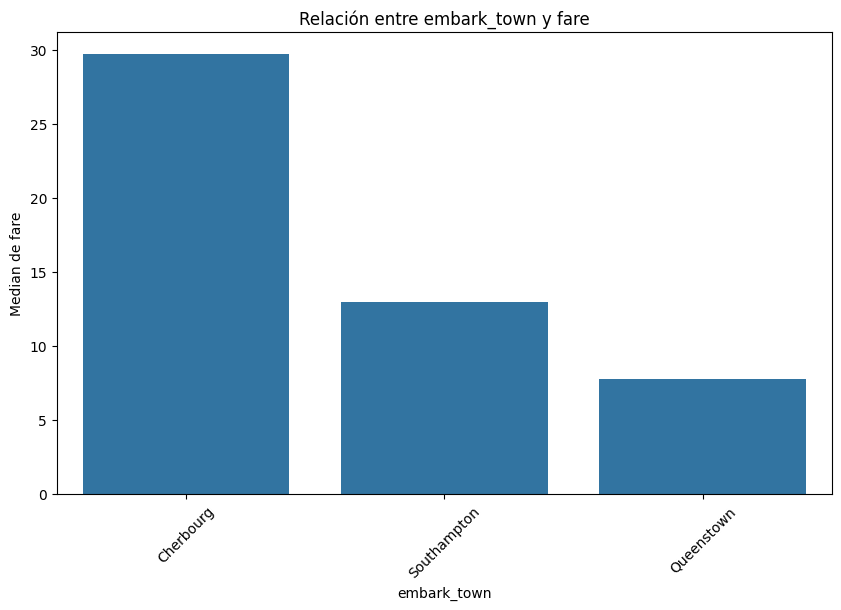

Distribución del precio para alive = yes


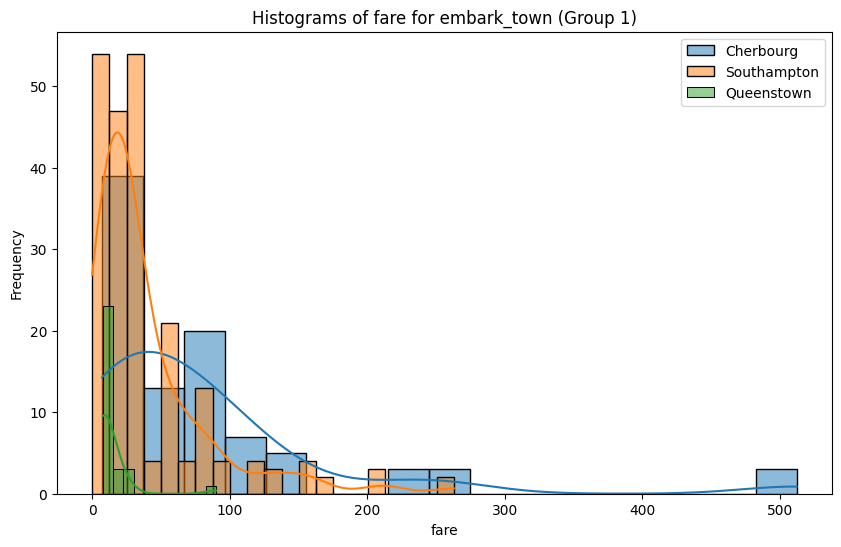

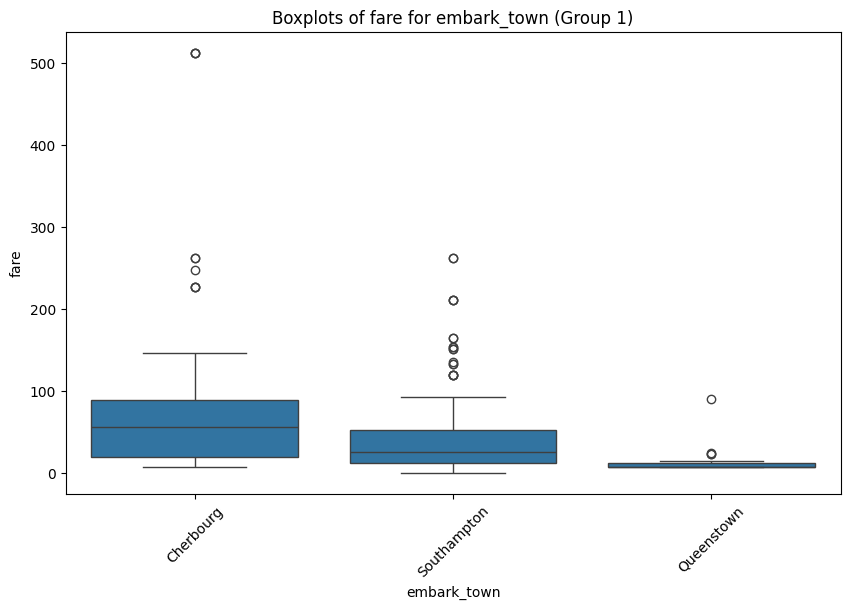

Distribución del precio para alive = no


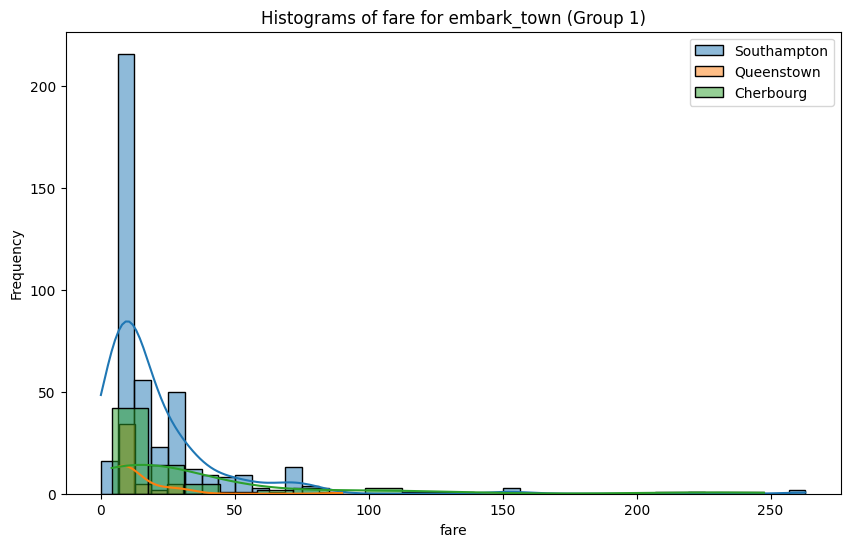

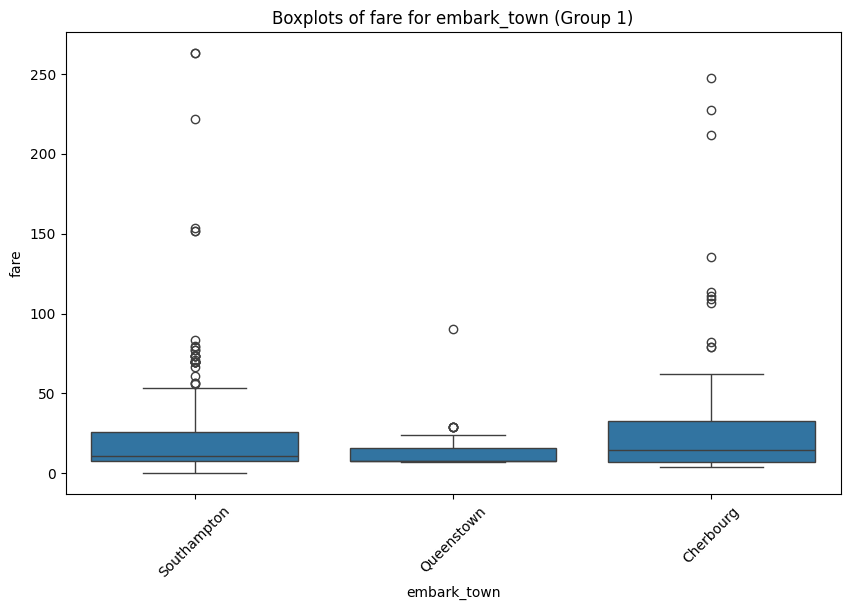

In [26]:
# 6) Relación entre el precio del billete, la ciudad de embarque y la supervivencia

# Resumen numérico del precio del billete por ciudad y estado de supervivencia
print(df.groupby(["embark_town", "alive"])["fare"].agg(["count", "mean", "median"]).round(2))

# Relación entre ciudad de embarque y precio del billete usando la mediana como medida central
bvt.plot_categorical_numerical_relationship(df, "embark_town", "fare", measure="median")

# Analizamos por separado a los supervivientes y a los fallecidos
for estado in ["yes", "no"]:
    # Filtramos solo las filas del estado actual de supervivencia
    subconjunto = df.loc[df["alive"] == estado, ["embark_town", "fare"]].copy()

    # Mostramos la distribución del precio del billete según la ciudad de embarque
    print(f"Distribución del precio para alive = {estado}")
    bvt.plot_grouped_histograms(subconjunto, "embark_town", "fare", group_size=3)

    # Mostramos boxplots para comparar visualmente la dispersión y posibles valores atípicos
    bvt.plot_grouped_boxplots(subconjunto, "embark_town", "fare")

Podemos ver que en Chesbourg se concentraba una mayor cantidad de tickets caros que en el resto de ciudades y cuando comparamos eso con la supervivencia, observamos que existe muy baja proporción de muertes de gente de Chesbourg y la mayoría son de la gente que pagó los billetes baratos. Por lo tanto, existe una relación entre supervivencia y tarifa, y esta tarifa a su vez está ligada con la ciudad de partida.

7. Ahondando en la relación entre sobrevivir o fallecer, la clase en la que se viajó y la edad de los pasajeros. ¿Qué agrupación de las dos variables (clase y edad) sobrevivió más en términos absolutos y en términos relativos?

alive                   no  yes
class  cat_age                 
First  (-0.581, 22.0]    6   23
       (22.0, 32.0]     11   37
       (32.0, 35.0]     17   18
       (35.0, 80.0]     46   58
Second (-0.581, 22.0]   12   29
       (22.0, 32.0]     38   28
       (32.0, 35.0]     16   11
       (35.0, 80.0]     31   19
Third  (-0.581, 22.0]  115   46
       (22.0, 32.0]     98   56
       (32.0, 35.0]    102   11
       (35.0, 80.0]     57    6
Relación class vs cat_age para alive = yes


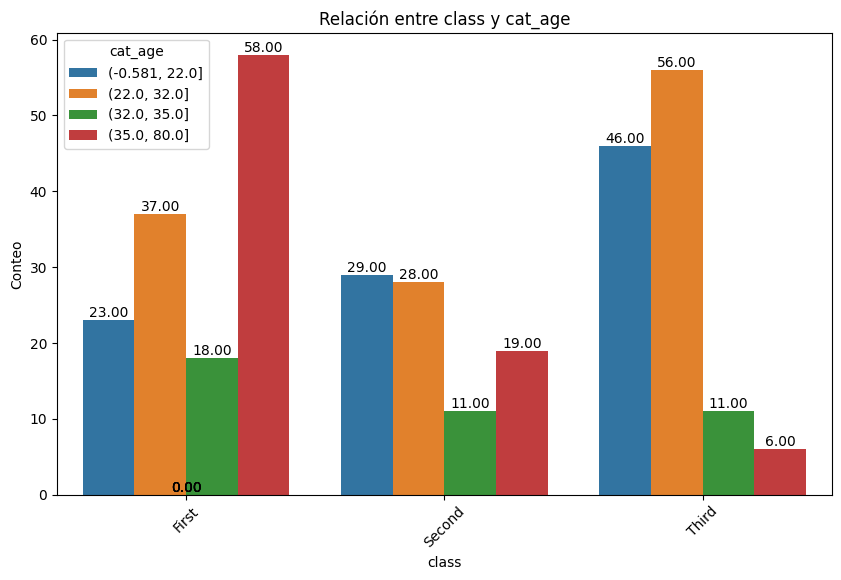

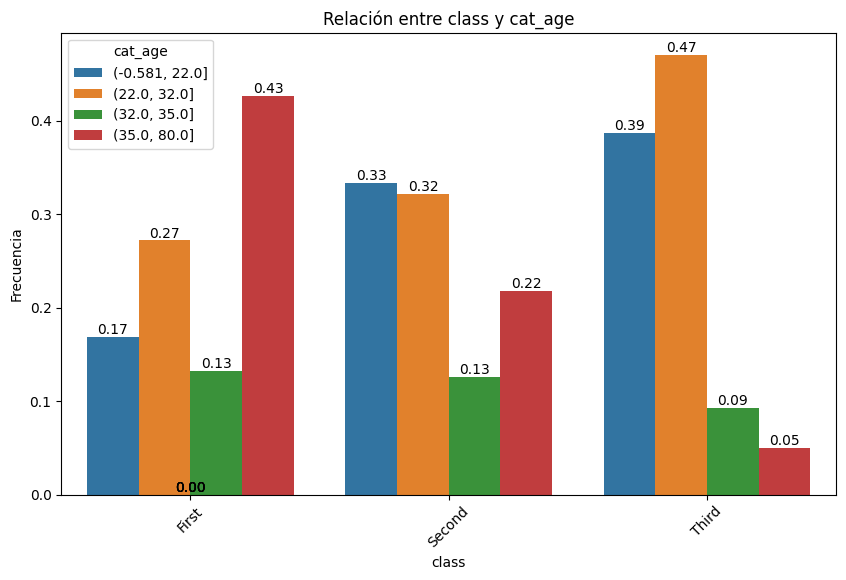

Relación class vs cat_age para alive = no


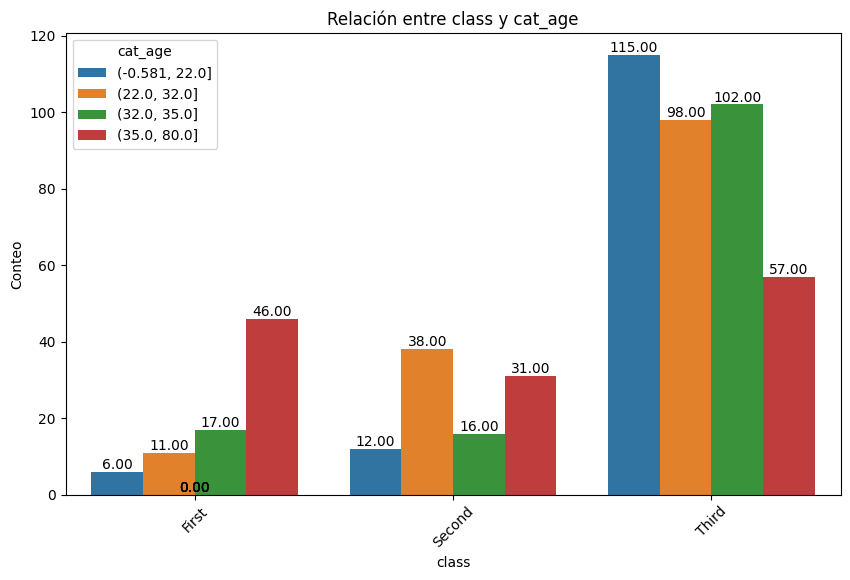

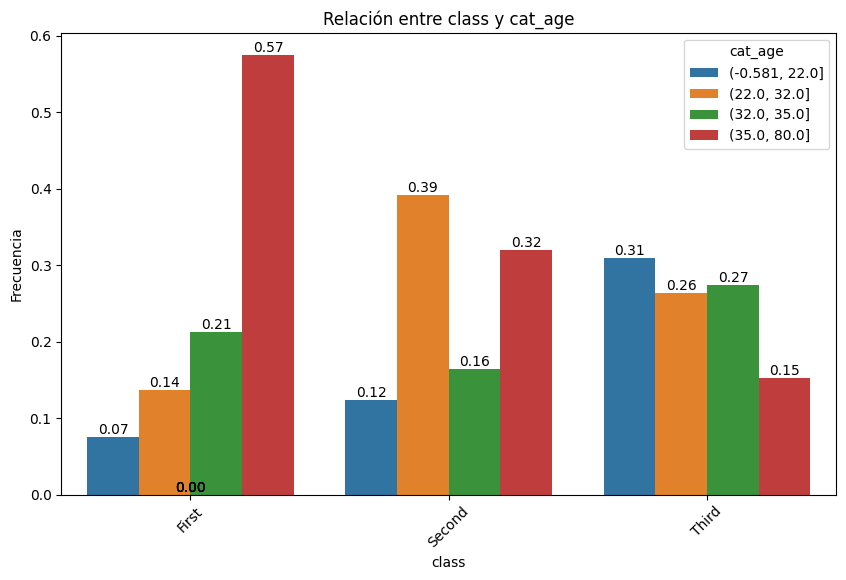

In [15]:
# 7) Relación entre clase y edad

# Calculamos los cuartiles de la variable edad para crear intervalos representativos
q1, q2, q3 = df["age"].quantile([0.25, 0.50, 0.75]).tolist()

# Definimos los cortes de edad usando el mínimo, cuartiles y máximo
cortes_edad = [df["age"].min() - 1, q1, q2, q3, df["age"].max()]

# Redondeamos y eliminamos posibles duplicados en los cortes
cortes_edad = sorted(set(round(valor, 2) for valor in cortes_edad))

# Si por algún motivo quedan menos de 5 cortes, usamos unos intervalos de respaldo
if len(cortes_edad) < 5:
    cortes_edad = [0, 18, 30, 45, df["age"].max()]

# Creamos una variable categórica de edad a partir de los intervalos definidos
df["cat_age"] = pd.cut(
    df["age"],
    bins=cortes_edad,
    include_lowest=True,
    duplicates="drop",
)

# Mostramos la tabla de contingencia entre clase, edad categorizada y supervivencia
print(pd.crosstab([df["class"], df["cat_age"]], df["alive"]))

# Analizamos la relación entre clase y edad para cada estado de supervivencia
for estado in ["yes", "no"]:
    # Filtramos los datos del estado actual
    subconjunto = df.loc[df["alive"] == estado, ["class", "cat_age"]].copy()

    # Mostramos el gráfico en términos absolutos
    print(f"Relación class vs cat_age para alive = {estado}")
    bvt.plot_categorical_relationship_fin(
        subconjunto, "class", "cat_age", relative_freq=False, show_values=True
    )

    # Mostramos el gráfico en términos relativos
    bvt.plot_categorical_relationship_fin(
        subconjunto, "class", "cat_age", relative_freq=True, show_values=True
    )

En terminos absolutos, los mayores de 35 años de primera clase son los que tienen mejor supervivencia. En terminos relativos, los adultos entre 22 y 32 años de tercera clase son los que más sobrevivieron

8. Finalmente, muestra las posibles relaciones entre edad, coste del billete y supervivencia/fallecimiento. ¿Qué puedes decir al respecto?

         age   fare
alive              
no     31.17  22.12
yes    28.95  48.40
Relación edad-precio para alive = yes


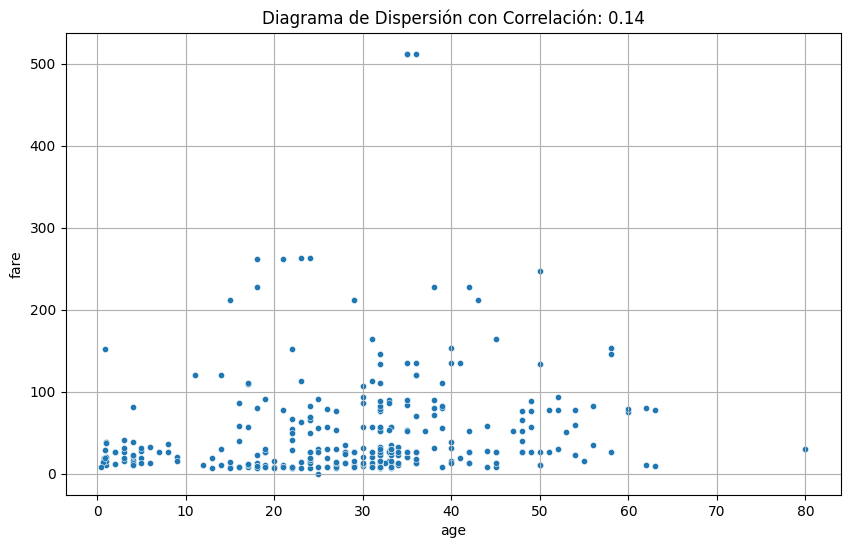

Relación edad-precio para alive = no


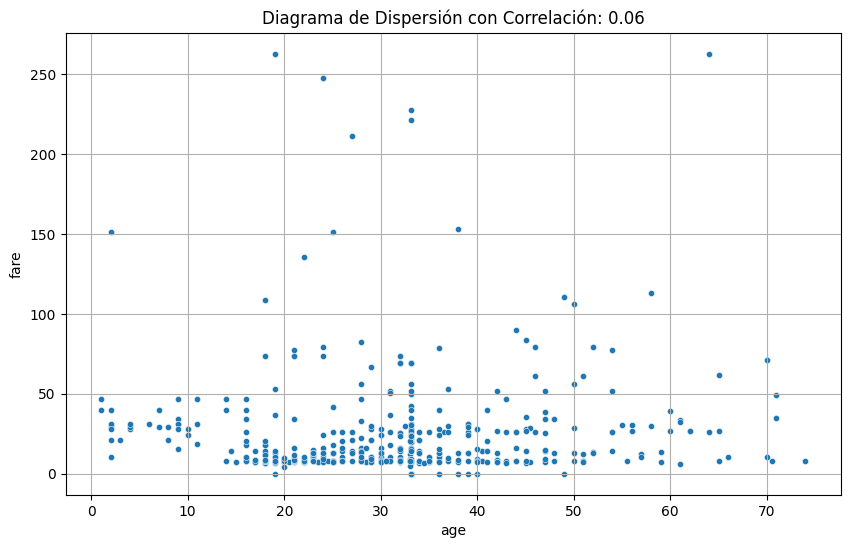

In [ ]:
# 8) Edad, billete y supervivencia
# Mostramos la media de edad y de tarifa por cada estado de supervivencia (yes/no)
print(df.groupby("alive")[["age", "fare"]].mean().round(2))

for estado in ["yes", "no"]:
    # Creamos un subconjunto con las columnas de interés para el estado actual
    subconjunto = df.loc[df["alive"] == estado, ["age", "fare"]].copy()
    # Indicamos en salida qué grupo estamos visualizando
    print(f"Relación edad-precio para alive = {estado}")
    # Gráfico de dispersión entre edad y tarifa, mostrando la correlación y ajustando el tamaño de los puntos
    bvt.grafico_dispersion_con_correlacion(subconjunto, "age", "fare", tamano_puntos=20, mostrar_correlacion=True)

## #EXTRA: Viajes

El objetivo en este caso no es tanto hacer un montón de análisis sino de completar lo que quedó pendiente en el workout y de entender cómo de un dataset podemos obtener preguntas o hipótesis interesantes (si las hay)

### #EXTRA.1 

Carga el dataset de viajes del mes de junio. Repite el análisis bivariante entre las variables "Aircompany" e "Ingresos", mostrando previamente los viajes por compañía aérea. ¿Qué situación llamativa nos surgió? (Ten en cuenta que somos el departamenteo de DataScience de TabarAir)

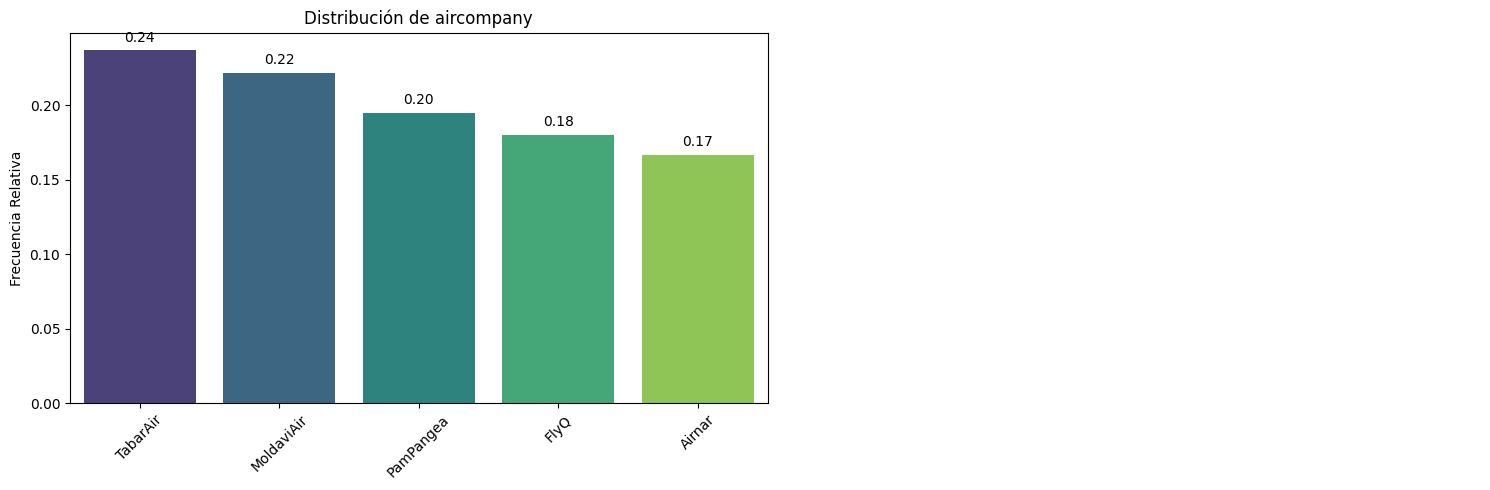

            vuelos  ingresos_totales  ingresos_medios
aircompany                                           
TabarAir       142       38487996.70    271042.230282
Airnar         100       40529397.82    405293.978200
FlyQ           108       43374852.87    401619.008056
PamPangea      117       55974794.70    478417.048718
MoldaviAir     133       72894268.81    548077.209098


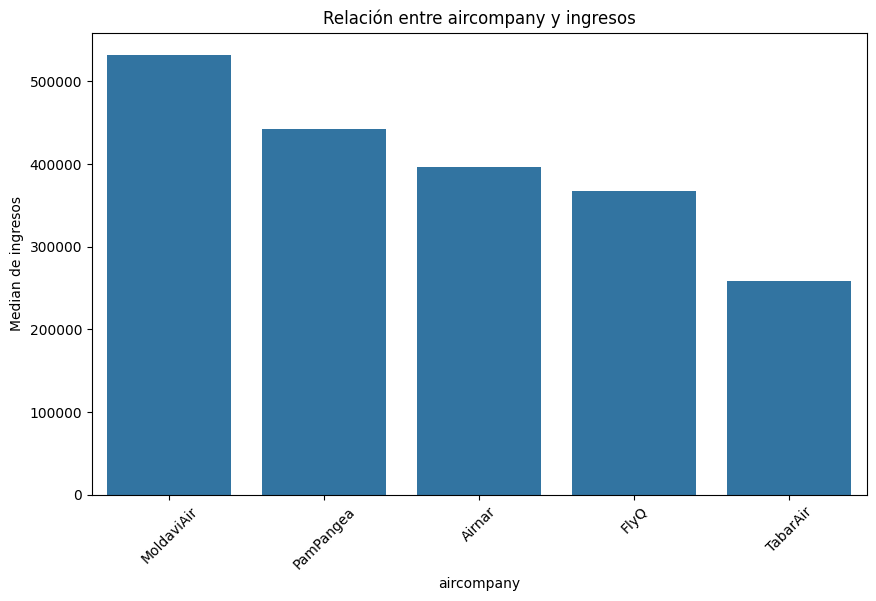

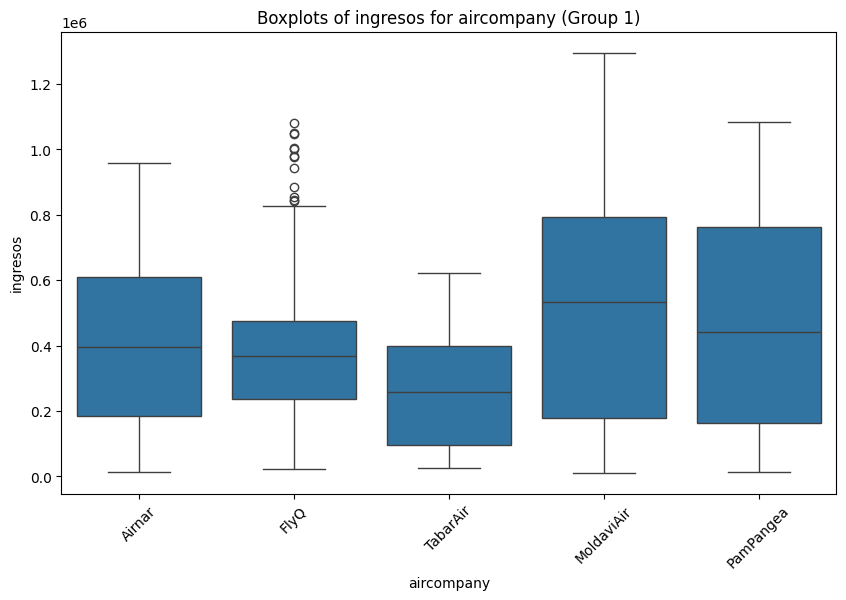

In [17]:
# Cargamos el fichero de vuelos de junio y miramos primero la distribución de compañías
df_viajes = pd.read_csv("./data/dataset_viajes_jun.csv")
bvt.pinta_distribucion_categoricas(df_viajes, ["aircompany"], relativa=True, mostrar_valores=True)

# Resumen numérico para comparar volumen e ingresos por aerolínea
resumen_viajes = df_viajes.groupby("aircompany").agg(
    vuelos=("destino", "size"),
    ingresos_totales=("ingresos", "sum"),
    ingresos_medios=("ingresos", "mean"),
).sort_values("ingresos_totales")
print(resumen_viajes)

# Relación bivariante entre compañía e ingresos
bvt.plot_categorical_numerical_relationship(df_viajes, "aircompany", "ingresos", measure="median")
bvt.plot_grouped_boxplots(df_viajes, "aircompany", "ingresos")

### #EXTRA.2

Repite el análisis multivariante entre "ingresos","distancias" y "consumo_kg". ¿Qué veíamos que parecía también muy prometedor?

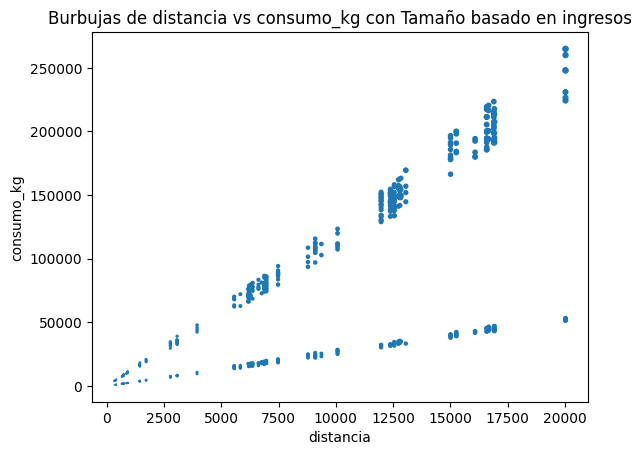

            ingresos  distancia  consumo_kg
ingresos       1.000      0.929       0.945
distancia      0.929      1.000       0.762
consumo_kg     0.945      0.762       1.000


In [18]:
# Visualizamos la relación entre distancia, consumo y facturación
bvt.bubble_plot(df_viajes, "distancia", "consumo_kg", "ingresos", scale=100000)

# Como apoyo, revisamos la correlación simple entre las tres variables
print(df_viajes[["ingresos", "distancia", "consumo_kg"]].corr().round(3))

### #EXTRA.3

Crea una variable categorica "cat_vuelo" a partir de distancias, escoge los rangos de las categorías basándote en la distribución de valores de "distancia" (sugerencia entre 3 y 4 categorías). Extra: Reaiza ahora otra vez el análisis multivariante "cat_vuelo", "ingresos", "consumo_kg". ¿Ves algo diferente?

cat_vuelo
(343.999, 3073.0]     170
(3073.0, 6877.0]      131
(6877.0, 12553.0]     157
(12553.0, 20029.0]    142
Name: count, dtype: int64
cat_vuelo   (343.999, 3073.0]  (3073.0, 6877.0]  (6877.0, 12553.0]  \
aircompany                                                           
Airnar                     31                12                 40   
FlyQ                       24                34                 22   
MoldaviAir                 34                19                 25   
PamPangea                  33                23                 19   
TabarAir                   48                43                 51   

cat_vuelo   (12553.0, 20029.0]  
aircompany                      
Airnar                      17  
FlyQ                        28  
MoldaviAir                  55  
PamPangea                   42  
TabarAir                     0  
Relación consumo-ingresos para (343.999, 3073.0]


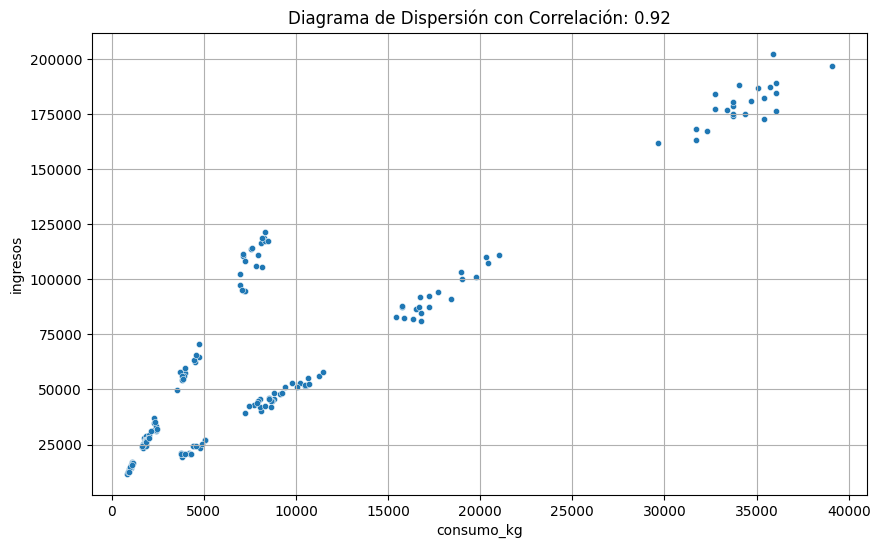

Relación consumo-ingresos para (3073.0, 6877.0]


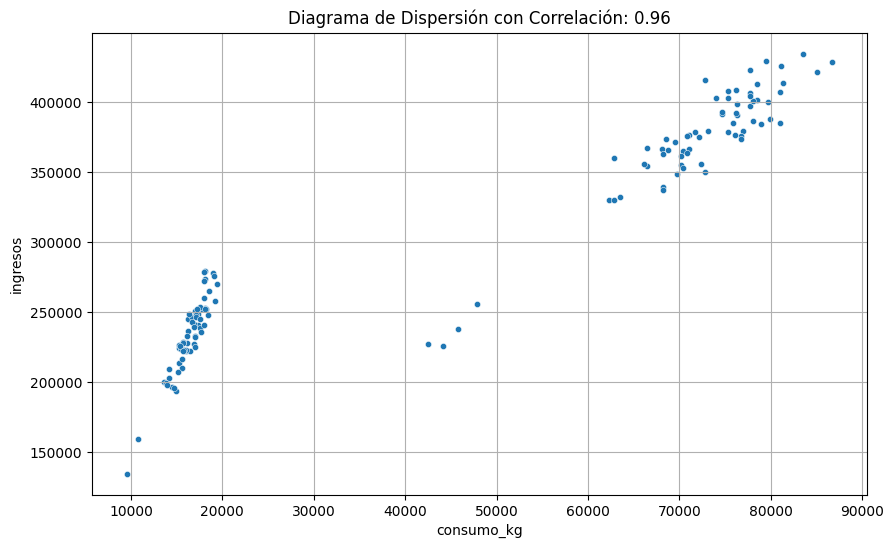

Relación consumo-ingresos para (6877.0, 12553.0]


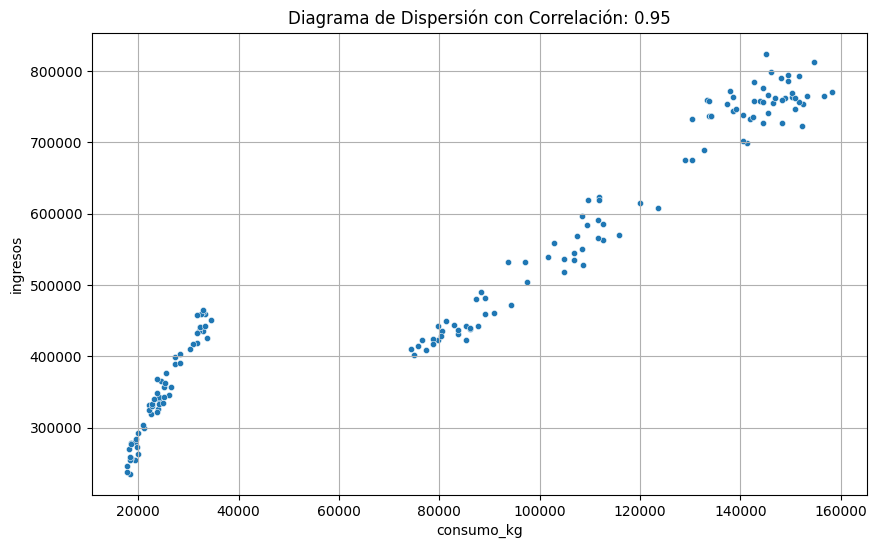

Relación consumo-ingresos para (12553.0, 20029.0]


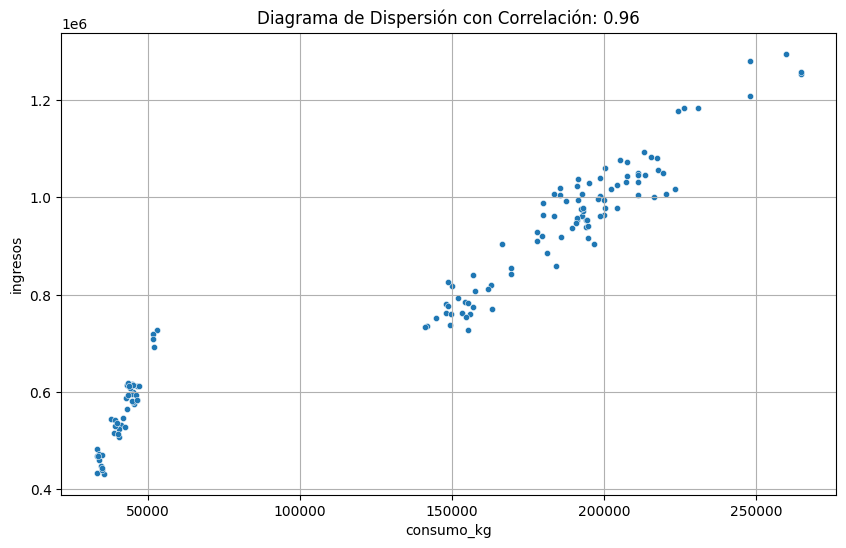

cat_vuelo
(343.999, 3073.0]      69372.75
(3073.0, 6877.0]      305331.33
(6877.0, 12553.0]     524261.03
(12553.0, 20029.0]    825074.34
Name: ingresos, dtype: float64


In [19]:
# Creamos la categoría de vuelo a partir de los cuartiles de distancia
df_viajes["cat_vuelo"] = pd.qcut(df_viajes["distancia"], q=4, duplicates="drop")
print(df_viajes["cat_vuelo"].value_counts().sort_index())
print(pd.crosstab(df_viajes["aircompany"], df_viajes["cat_vuelo"]))

# Repetimos el análisis multivariante por tramos de distancia
for categoria in df_viajes["cat_vuelo"].cat.categories:
    subconjunto = df_viajes.loc[df_viajes["cat_vuelo"] == categoria, ["consumo_kg", "ingresos"]].copy()
    print(f"Relación consumo-ingresos para {categoria}")
    bvt.grafico_dispersion_con_correlacion(subconjunto, "consumo_kg", "ingresos", tamano_puntos=20, mostrar_correlacion=True)

# Y miramos si los ingresos medios cambian entre tramos
print(df_viajes.groupby("cat_vuelo", observed=False)["ingresos"].mean().round(2))